In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [17]:
df = pd.read_csv('./test_data.csv')

In [18]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
72,LP001877,Male,Yes,2,Graduate,No,4708,1387.0,150.0,360.0,1.0,Semiurban,Y
73,LP001319,Male,Yes,2,Not Graduate,No,3273,1820.0,81.0,360.0,1.0,Urban,Y
74,LP002272,Male,Yes,2,Graduate,No,3276,484.0,135.0,360.0,NaN,Semiurban,Y
75,LP002407,Female,Yes,0,Not Graduate,Yes,7142,0.0,138.0,360.0,1.0,Rural,Y
76,LP002840,Female,No,0,Graduate,No,2378,0.0,9.0,360.0,1.0,Urban,N


In [19]:
print(df['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.727273
N    0.272727
Name: proportion, dtype: float64


In [20]:
print(df.duplicated().sum())

0


In [21]:
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [22]:
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents               str
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [23]:
#null values percentage
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           1.298701
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     2.597403
Credit_History       9.090909
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [24]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_7214/3390244665.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_7214/3390244665.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace meth

0     0
1     0
2     0
3     1
4     0
     ..
72    0
73    0
74    0
75    1
76    0
Name: Self_Employed, Length: 77, dtype: int64

In [25]:
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            77 non-null     int64  
 1   Gender             77 non-null     int64  
 2   Married            77 non-null     int64  
 3   Dependents         76 non-null     str    
 4   Education          77 non-null     int64  
 5   Self_Employed      77 non-null     int64  
 6   ApplicantIncome    77 non-null     int64  
 7   CoapplicantIncome  77 non-null     float64
 8   LoanAmount         77 non-null     float64
 9   Loan_Amount_Term   77 non-null     float64
 10  Credit_History     77 non-null     float64
 11  Property_Area      77 non-null     int64  
 12  Loan_Status        77 non-null     int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 7.9 KB


In [27]:
df.describe()

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,38.000000,0.779221,0.571429,0.272727,0.233766,3564.116883,1500.854545,103.818182,336.623377,0.909091,1.116883,0.727273
std,22.371857,0.476373,0.498117,0.448282,0.535481,1624.392080,3920.776382,27.132583,73.042352,0.289365,0.777547,0.448282
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,36.000000,0.000000,0.000000,0.000000
25%,19.000000,1.000000,0.000000,0.000000,0.000000,2378.000000,0.000000,88.000000,360.000000,1.000000,1.000000,0.000000
50%,38.000000,1.000000,1.000000,0.000000,0.000000,3200.000000,985.799988,110.000000,360.000000,1.000000,1.000000,1.000000
75%,57.000000,1.000000,1.000000,1.000000,0.000000,4384.000000,1820.000000,120.000000,360.000000,1.000000,2.000000,1.000000
max,76.000000,2.000000,1.000000,1.000000,2.000000,8624.000000,33837.000000,150.000000,480.000000,1.000000,2.000000,1.000000


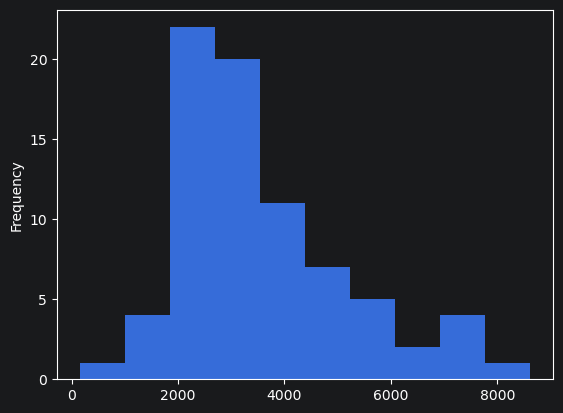

In [28]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

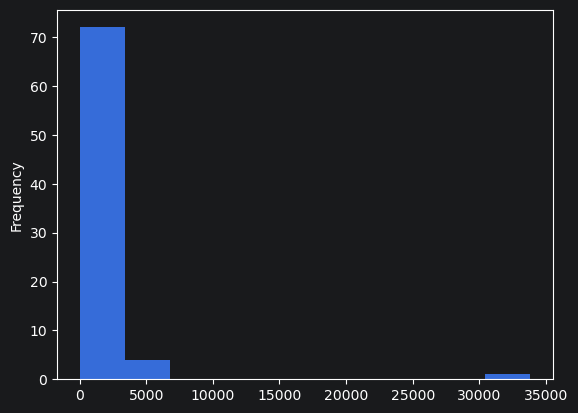

In [29]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [30]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

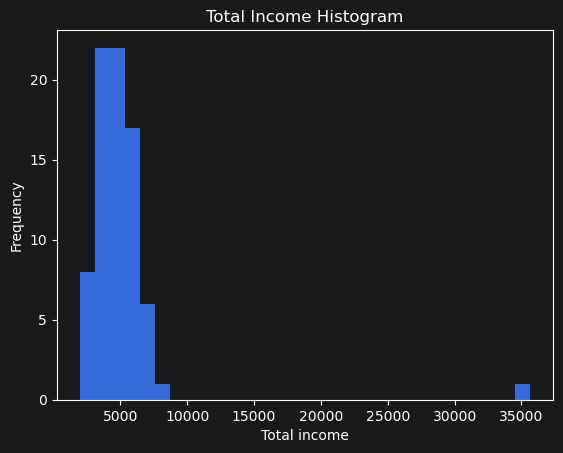

In [31]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

In [32]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents               str
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


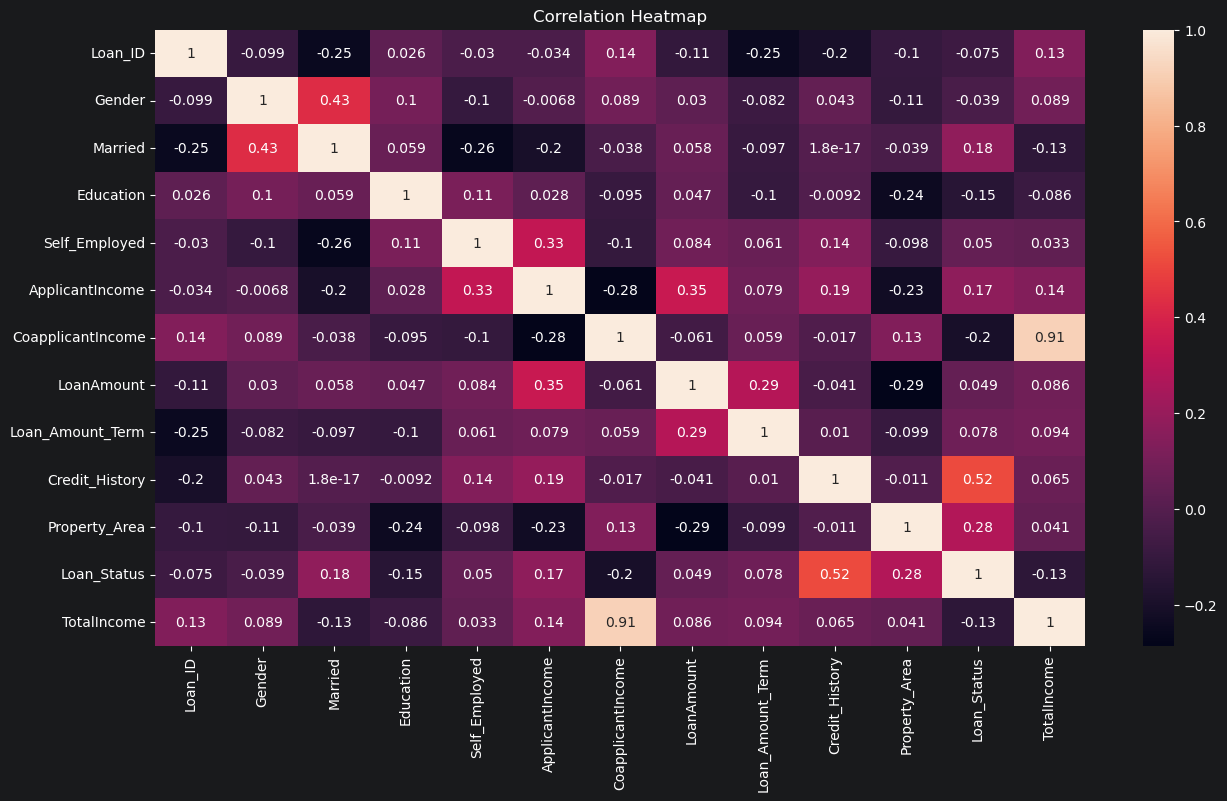

In [33]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [34]:
#dropped because the correlation coofecient between it and the loan status is low
#df = df.drop('Gender', axis = 1, errors = 'ignore')

In [35]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,56,1,1,0,0,0,5829,0.0,138.0,360.0,1.0,0,1,5829.0
1,42,1,1,1,0,0,1625,1803.0,96.0,360.0,1.0,2,1,3428.0
2,14,1,1,3+,0,0,3029,0.0,99.0,360.0,1.0,2,1,3029.0
3,15,1,1,1,0,1,1000,3022.0,110.0,360.0,1.0,2,0,4022.0
4,17,0,0,0,0,0,3846,0.0,111.0,360.0,1.0,1,1,3846.0


In [36]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
72,39,1,1,2,0,0,4708,1387.0,150.0,360.0,1.0,1,1,6095.0
73,18,1,1,2,1,0,3273,1820.0,81.0,360.0,1.0,2,1,5093.0
74,53,1,1,2,0,0,3276,484.0,135.0,360.0,1.0,1,1,3760.0
75,58,0,1,0,1,1,7142,0.0,138.0,360.0,1.0,0,1,7142.0
76,70,0,0,0,0,0,2378,0.0,9.0,360.0,1.0,2,0,2378.0


In [37]:
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']

In [38]:
#null values percentage
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           1.298701
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
TotalIncome          0.000000
dtype: float64

In [39]:
x = df[features]
y = df['Loan_Status']

In [40]:
df['Dependents'] = df['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)

In [41]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


In [42]:
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=1)
model.fit(x, y)

ValueError: could not convert string to float: '3+'

In [ ]:
tdf = pd.read_csv("/content/test_data.csv")
tdf['TotalIncome'] = tdf['ApplicantIncome'] + tdf['CoapplicantIncome']
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
tdf['Gender'].fillna(tdf['Gender'].mode()[0], inplace=True)
tdf['Self_Employed'].fillna(tdf['Self_Employed'].mode()[0], inplace=True)

tdf['Loan_Amount_Term']=tdf["Loan_Amount_Term"].fillna(tdf['Loan_Amount_Term'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())

for col in categ_cols:
  tdf[col] = le.fit_transform(tdf[col])

tdf['Dependents'] = tdf['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
tdf['Dependents'] = pd.to_numeric(tdf['Dependents'], errors='coerce').fillna(0).astype(int)
print(tdf.dtypes)
x_test = tdf[features]
y_test = tdf['Loan_Status']

In [ ]:
predictions = model.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

In [ ]:
predictions = model.predict(x)
print(f"Model Accuracy: {accuracy_score(y, predictions)}")

In [ ]:
print(tdf['Loan_Status'].value_counts(normalize = 'true'))

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

In [ ]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc: .4f}")

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(x_train, y_train)

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = rf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

In [ ]:
predictions = rf.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

In [ ]:
predictions = rf.predict(x_train)
print(f"Model Accuracy: {accuracy_score(y_train, predictions)}")

In [ ]:
from sklearn.metrics import classification_report

# This will show you exactly where the 0.8966 is coming from
print(classification_report(y_test, y_pred))
